# 08. sRNA どうしが Hfq を奪い合う — 競合とクロストーク

> **出典**: Moon K, Gottesman S (2011) *Competition among Hfq-binding small RNAs in Escherichia coli.* Mol Microbiol 82(6):1545-1562.

この論文は実験（Northern blot）が主で数式は無い。でも確立した結論はモデル化にうってつけ:

- **Hfq は量が限られた共有資源**。ある sRNA（例 OxyS）を過剰発現すると Hfq を奪い、
  他の sRNA（例 DsrA→RpoS）の蓄積・活性が下がる = **競合＝クロストーク**。
- **Hfq を増やすと、この競合は緩和・逆転する**（rescue）。

そこで 06/07 の Hfq 陽モデルを、**2つの sRNA-mRNA 系（s1/m1 と s2/m2）が1つの Hfq を共有**する形へ拡張し、
この2つの予測を再現する。s2/m2 を「レポーター」、s1 を過剰発現する「競合者」とする。
各系のモジュールは 06/07 とまったく同じ（sRNA/mRNA が Hfq に乗り→三者→duplex）。

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species

H = Species('H')
BETA, KA, KD, K5 = 1.0, 1.0, 1.0, 10.0
def R(a,b,k): return ReactionRule(a,b,k)

def pair_rules(i, a_s, a_m):
    s,m,sH,mH,T,D = (Species(f'{x}{i}') for x in ['s','m','sH','mH','T','D'])
    return [R([],[s],a_s), R([],[m],a_m), R([s],[],BETA), R([m],[],BETA),
            R([s,H],[sH],KA), R([sH],[s,H],KD), R([m,H],[mH],KA), R([mH],[m,H],KD),
            R([sH,m],[T],KA), R([T],[sH,m],KD), R([mH,s],[T],KA), R([T],[mH,s],KD),
            R([T],[D,H],K5), R([sH],[H],BETA), R([mH],[H],BETA), R([T],[H],BETA), R([D],[],BETA)]

NAMES = ['H'] + [f'{x}{i}' for i in (1,2) for x in ['s','m','sH','mH','T','D']]

def build(h_tot, a_s1):
    mdl = NetworkModel()
    for r in pair_rules(1, a_s1, 10.0) + pair_rules(2, 10.0, 10.0):
        mdl.add_reaction_rule(r)
    return mdl

def activities(h_tot, a_s1):
    ret = run_simulation(600.0, y0={'H': h_tot}, model=build(h_tot, a_s1),
                         solver='ode', ndiv=1, species_list=NAMES)
    v = dict(zip(NAMES, ret.as_array()[-1][1:]))
    def pct(i):
        tot = v[f'm{i}']+v[f'mH{i}']+v[f'T{i}']+v[f'D{i}']
        return 100*v[f'D{i}']/tot if tot > 0 else 0.0
    return pct(1), pct(2)
print('ready')

ready


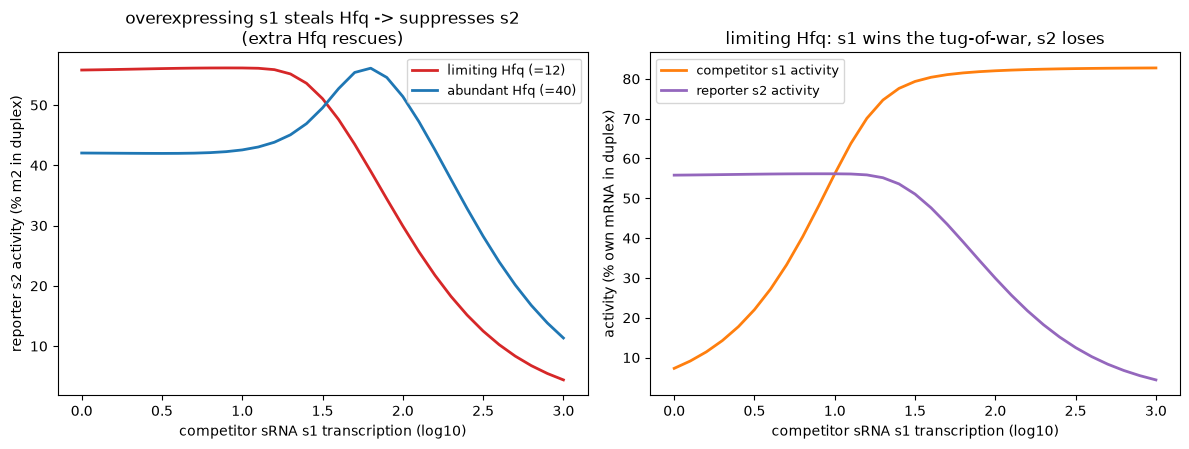

In [2]:
a_grid = np.logspace(0, 3, 31)   # 競合 sRNA s1 の転写量（過剰発現）
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

for h_tot, c, lab in [(12.0,'C3','limiting Hfq (=12)'), (40.0,'C0','abundant Hfq (=40)')]:
    y = np.array([activities(h_tot, a)[1] for a in a_grid])
    ax1.plot(np.log10(a_grid), y, '-', color=c, lw=2, label=lab)
ax1.set_xlabel('competitor sRNA s1 transcription (log10)')
ax1.set_ylabel('reporter s2 activity (% m2 in duplex)')
ax1.set_title('overexpressing s1 steals Hfq -> suppresses s2\n(extra Hfq rescues)'); ax1.legend(fontsize=9)

a1 = np.array([activities(12.0, a)[0] for a in a_grid])
a2 = np.array([activities(12.0, a)[1] for a in a_grid])
ax2.plot(np.log10(a_grid), a1, '-', color='C1', lw=2, label='competitor s1 activity')
ax2.plot(np.log10(a_grid), a2, '-', color='C4', lw=2, label='reporter s2 activity')
ax2.set_xlabel('competitor sRNA s1 transcription (log10)')
ax2.set_ylabel('activity (% own mRNA in duplex)')
ax2.set_title('limiting Hfq: s1 wins the tug-of-war, s2 loses'); ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 読み取り

- **左**: 競合 sRNA s1 を過剰発現していくと、レポーター s2 の活性が落ちる。**Hfq 律速（赤）だと急落**するが、
  **Hfq が潤沢（青）だと競合下でも保たれる** = 論文の「extra Hfq が競合を rescue」。
- **右**: Hfq 律速下で s1 と s2 を同時に見ると、**s1 が Hfq を勝ち取って活性を上げる裏で s2 が負ける**という綱引き。
  これが「sRNA 競合のヒエラルキー」で、塩基対合を介さない（Hfq を介した）間接的な制御になっている。

**含意**: sRNA は独立に働くのではなく、Hfq という共有資源を通じて**互いに干渉する**。ある sRNA を誘導する
ストレス応答が、無関係な別の経路を意図せず弱める、ということが起こりうる。

**06/07 との関係**: 06 で Hfq を資源として陽に入れ、07 で最適 Hfq を示した。08 はその資源を**複数の sRNA が奪い合う**
自然な次の一歩。単一ペアの set-point が、ネットワークでは「誰が Hfq を取るか」の競争になる。

## 練習問題

1. s1 の Hfq 結合を強く（`KA` を s1 だけ上げる）すると、より少ない発現量で s2 を抑えられるか＝「強い競合者」を作る。
2. 3つ目の sRNA s3 を足して、誘導の順序で誰が生き残るかを見る。
3. レポーター s2 の標的 m2 の転写量を変えると、競合への感受性は変わる？
4. [[bio-a_hfq-phylogenetics]]: Hfq 結合親和性がオーソログ間で違えば「競合ヒエラルキー」の順位が変わりうる。
   Hfq や sRNA の配列進化を、この奪い合いの強さの差として解釈してみる。